# Python GIS Procedural Pipeline

This notebook implements an end-to-end pipeline:
1. Draw a polygon on an interactive map
2. Extract GeoJSON & transform coordinates to UTM (CCW ordering)
3. Generate a procedural building with PyPRT (CityEngine)
4. Visualize the 3D model with Autodesk Viewer

## تثبيت المكتبات (Install Libraries)

If running outside the project venv, uncomment the following line:
```
# !pip install leafmap shapely pyproj pyprt pythreejs ipywidgets trimesh
```

---
## الخلية 1: إعداد الخريطة ورسم المضلع
## Cell 1: Interactive Map & Polygon Drawing

In [5]:
import leafmap

m = leafmap.Map(center=[15, 45], zoom=16)

# The draw tool is available by default in leafmap.
# Draw a polygon on the map below, then proceed to Cell 2.
m

Map(center=[15, 45], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_tex…

---
## الخلية 2: استخراج GeoJSON وتحويل الإحداثيات إلى UTM وترتيب CCW
## Cell 2: Extract GeoJSON → Transform to UTM → Ensure CCW Winding

إحداثيات Lat/Lon الأصلية (Original Lat/Lon coordinates):
[(45.00065, 15.000615), (45.00065, 15.001112), (45.001079, 15.001112), (45.001079, 15.000615), (45.00065, 15.000615)]

تم تحويل الإحداثيات إلى UTM وترتيبها CCW بنجاح
(Coordinates transformed to UTM and ordered CCW successfully)

UTM Coords (5 vertices):
  [0] x=500069.88, y=1658394.02
  [1] x=500116.00, y=1658394.02
  [2] x=500116.00, y=1658448.99
  [3] x=500069.88, y=1658448.99
  [4] x=500069.88, y=1658394.02


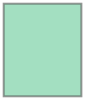

Map(center=[15, 45], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_tex…

In [6]:
from shapely.geometry import shape, Polygon
from pyproj import Transformer

if len(m.draw_features) == 0:
    raise RuntimeError("لم يتم رسم أي مضلع بعد — No polygon drawn yet. Run Cell 1 and draw a polygon first.")

# Take the most recently drawn feature
geojson_feature = m.draw_features[-1]
polygon = shape(geojson_feature['geometry'])
coords = list(polygon.exterior.coords)

print("إحداثيات Lat/Lon الأصلية (Original Lat/Lon coordinates):")
print(coords)

# Transform from WGS84 (EPSG:4326) to UTM Zone 38N (EPSG:32638)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32638", always_xy=True)
utm_coords = [transformer.transform(x, y) for x, y in coords]
utm_polygon = Polygon(utm_coords)

# Ensure counter-clockwise (CCW) winding order
if not utm_polygon.exterior.is_ccw:
    utm_coords = list(utm_polygon.exterior.coords)[::-1]
    utm_polygon = Polygon(utm_coords)

print("\nتم تحويل الإحداثيات إلى UTM وترتيبها CCW بنجاح")
print("(Coordinates transformed to UTM and ordered CCW successfully)")
print(f"\nUTM Coords ({len(utm_coords)} vertices):")
for i, c in enumerate(utm_coords):
    print(f"  [{i}] x={c[0]:.2f}, y={c[1]:.2f}")

from IPython.display import display
display(utm_polygon)  # Show the 2D polygon shape

# Create an interactive map for the extracted feature
m2 = leafmap.Map(center=[15, 45], zoom=16)
fc = {"type": "FeatureCollection", "features": [geojson_feature]}
m2.add_geojson(fc, layer_name="Extracted Polygon")
m2

---
## الخلية 3: إرسال الشكل إلى PyPRT وتوليد المبنى Procedural
## Cell 3: Send Shape to PyPRT & Generate Procedural Building

In [7]:
import pyprt, os, base64
import numpy as np

pyprt.initialize_prt()

# إخراج الإحداثيات للمبنى مع التوسيط (Centering) لضمان ظهوره في الفيوور
coords_2d = list(utm_polygon.exterior.coords)[:-1]

# حساب المركز (Centroid) لجعل الموديل حول نقطة الصفر (0,0,0)
center_x = sum(c[0] for c in coords_2d) / len(coords_2d)
center_y = sum(c[1] for c in coords_2d) / len(coords_2d)

flat_coords = []
for x, y in coords_2d:
    # طرح المركز لضمان التوسيط التام
    flat_coords.extend([x - center_x, 0.0, y - center_y])

initial_shape = pyprt.InitialShape(flat_coords)
attributes = {"Nbr_of_Floors": 12, "Usage": "Residential"}

RPK_PATH = r"C:\RPK\RuleFootprint.rpk"
model_generator = pyprt.ModelGenerator([initial_shape])

encoder = "com.esri.prt.codecs.GLTFEncoder"
out_dir = os.path.join(os.getcwd(), "output_models")
os.makedirs(out_dir, exist_ok=True)

encoder_options = {
    "outputPath": out_dir,
    "baseName": "procedural_building"
}

# توليد المبنى
model_generator.generate_model([attributes], RPK_PATH, encoder, encoder_options)

# قراءة الملف وتحويله لـ Base64
glb_path = os.path.join(out_dir, "procedural_building_0.glb")
with open(glb_path, "rb") as f:
    glb_data = f.read()

model_b64 = base64.b64encode(glb_data).decode('utf-8')

print(f"✅ Model Centered and Ready!")
print(f"Shifted by Central Offset: X={center_x:.2f}, Y={center_y:.2f}")


[PRT] [2026-03-12 05:42:07] [warning] CGB file contains warning 'Potentially problematic CGAC version 1.16 : major number smaller than current (2.10). Recompiling with current CGA Compiler is recommended.'
✅ Model Centered and Ready!
Shifted by Central Offset: X=500092.94, Y=1658421.50


---
## الخلية 4: عرض النموذج باستخدام Autodesk Viewer
## Cell 4: Visualize the Model with Autodesk Viewer

In [8]:
import os
import webbrowser
from IPython.display import display, HTML

# كود الـ HTML المطور مع أدوات التحكم (Fly To / Axes)
html_template = """<!DOCTYPE html>
<html>
<head>
    <title>CityEngine Advanced Viewer</title>
    <meta charset=\"utf-8\">
    <style>
        body, html { margin: 0; padding: 0; width: 100%; height: 100%; overflow: hidden; font-family: 'Segoe UI', sans-serif; background: #1a1a1a; }
        #viewer-v15 { width: 100%; height: 100vh; }
        #toolbar { position: absolute; top: 20px; left: 20px; z-index: 100; display: flex; flex-direction: column; gap: 8px; }
        .btn { 
            background: #0076d1; color: white; border: none; padding: 10px 18px; 
            border-radius: 4px; cursor: pointer; font-weight: 600; font-size: 13px;
            box-shadow: 0 4px 6px rgba(0,0,0,0.2); transition: 0.2s;
            pointer-events: auto;
        }
        .btn:hover { background: #005ba1; }
        #status-panel { background: rgba(0,0,0,0.8); color: #00ff00; padding: 10px; border-radius: 4px; font-family: monospace; font-size: 12px; min-width: 200px; border-left: 3px solid #00ff00; }
    </style>
    <link rel=\"stylesheet\" href=\"https://developer.api.autodesk.com/modelderivative/v2/viewers/7.98/style.min.css\" type=\"text/css\">
    <script src=\"https://developer.api.autodesk.com/modelderivative/v2/viewers/7.98/viewer3D.min.js\"></script>
    <script src=\"https://developer.api.autodesk.com/modelderivative/v2/viewers/7.98/extensions/glTF/glTF.min.js\"></script>
</head>
<body>
    <div id='viewer-v15'></div>
    <div id='toolbar'>
        <div id='status-panel'>Initializing Systems...</div>
        <button class='btn' onclick='flyToModel()'>🚀 Fly to Model (Focus)</button>
        <button class='btn' style='background:#444' onclick='toggleAxes()'>📐 Toggle Center Axes</button>
    </div>

    <script>
    let viewer;
    let axes = null;
    const updateStatus = (m) => document.getElementById('status-panel').innerText = '> ' + m;
    
    function b64ToBlob(b64) {
        const bin = atob(b64);
        const buf = new Uint8Array(bin.length);
        for (let i = 0; i < bin.length; i++) buf[i] = bin.charCodeAt(i);
        return new Blob([buf], {type: 'model/gltf-binary'});
    }

    function flyToModel() {
        if (viewer) {
            viewer.fitToView();
            updateStatus('View Reset to Model Center');
        }
    }

    function toggleAxes() {
        if (!viewer) return;
        if (!axes) {
            axes = new THREE.AxesHelper(100);
            viewer.impl.scene.add(axes);
            updateStatus('Axes Helper Visible at (0,0,0)');
        } else {
            viewer.impl.scene.remove(axes);
            axes = null;
            updateStatus('Axes Helper Hidden');
        }
        viewer.impl.invalidate(true);
    }

    function start() {
        if (typeof Autodesk === 'undefined' || typeof Autodesk.Viewing.Extensions.glTF === 'undefined') {
            setTimeout(start, 300); return;
        }
        
        Autodesk.Viewing.Initializer({ env: 'Local' }, function() {
            viewer = new Autodesk.Viewing.GuiViewer3D(document.getElementById('viewer-v15'));
            viewer.start();
            viewer.setTheme('dark-theme');
            viewer.setEnvMapBackground(true);
            viewer.setLightPreset(1);
            
            const blob = b64ToBlob("{{MODEL_B64}}");
            const url = URL.createObjectURL(blob);
            
            updateStatus('Loading 3D Geometry...');
            
            viewer.loadModel(url + '#.glb', { fileExt: 'glb' }, (m) => {
                updateStatus('Model Loaded Success!');
                setTimeout(() => {
                    viewer.fitToView();
                    toggleAxes();
                }, 1000);
            }, (err) => {
                updateStatus('Error: ' + err);
            });
        });
    }
    start();
    </script>
</body>
</html>
"""

final_html = html_template.replace("{{MODEL_B64}}", model_b64)
html_filename = "viewer_v16.html"
with open(html_filename, "w", encoding="utf-8") as f:
    f.write(final_html)

full_path = os.path.abspath(html_filename)
webbrowser.open('file:///' + full_path.replace('\\', '/'))

display(HTML(f"""
<div style='border: 2px solid #0076d1; background: #f0f7ff; padding: 25px; border-radius: 12px; font-family: system-ui;'>
    <h2 style='color: #0076d1; margin-top: 0;'>🚀 تم تجهيز الفيوور المطور (V16)</h2>
    <p>بناءً على طلبك، أضفنا زر <b>🚀 Fly to Model</b> داخل الصفحة الجديدة.</p>
    <ul style='color: #444;'>
        <li>تم تفعيل <b>المحاور (Axes)</b> تلقائياً لمعرفة مركز المشهد.</li>
        <li>استخدم زر الفوكس إذا اختفى المبنى عن نظرك.</li>
    </ul>
    <a href='viewer_v16.html' target='_blank' 
       style='background: #0076d1; color: white; padding: 12px 25px; text-decoration: none; border-radius: 5px; font-weight: bold; display: inline-block; margin-top: 10px;'>
       🎮 فتح الفيوور التفاعلي الجديد
    </a>
</div>
"""))
